In [4]:
# Data Loading
import pandas as pd
df = pd.read_csv("SampleSuperstore.csv")

In [ ]:
#Understanding data

In [5]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [6]:
df.tail()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.248,3,0.2,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.960,2,0.0,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.576,2,0.2,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.600,4,0.0,13.3200
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.160,2,0.0,72.9480


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [8]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [10]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [11]:
#data cleaning
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [12]:
#remove duplicate
df.drop_duplicates(inplace=True)

In [14]:
#now analysis
#total sales and profit
df[['Sales','Profit']].sum()  

Sales     2.296196e+06
Profit    2.862414e+05
dtype: float64

In [15]:
#profit by category
df.groupby('Category')['Profit'].sum()

Category
Furniture           18421.8137
Office Supplies    122364.6608
Technology         145454.9481
Name: Profit, dtype: float64

In [16]:
#profit by sub categories
df.groupby('Sub-Category')['Profit'] .sum()

Sub-Category
Accessories    41936.6357
Appliances     18138.0054
Art             6524.6118
Binders        30228.0003
Bookcases      -3472.5560
Chairs         26567.1278
Copiers        55617.8249
Envelopes       6964.1767
Fasteners        949.5182
Furnishings    13052.7230
Labels          5526.3820
Machines        3384.7569
Paper          33944.2395
Phones         44515.7306
Storage        21278.8264
Supplies       -1189.0995
Tables        -17725.4811
Name: Profit, dtype: float64

In [17]:
#sales by category
df.groupby('Category') ['Sales'].sum()

Category
Furniture          741306.3133
Office Supplies    718735.2440
Technology         836154.0330
Name: Sales, dtype: float64

In [19]:
#now according to region
df.groupby('Region')['Profit'].sum()

Region
Central     39655.8752
East        91506.3092
South       46749.4303
West       108329.8079
Name: Profit, dtype: float64

In [20]:
#now profit according to city
df.groupby('City')['Profit'] .sum().sort_values(ascending=False).head(10)

City
New York City    62013.8973
Los Angeles      30431.4267
Seattle          29121.6825
San Francisco    17466.1186
Detroit          13146.6935
Lafayette        10018.3876
Jackson           7581.6828
Atlanta           6993.6629
Minneapolis       6824.5846
San Diego         6377.1960
Name: Profit, dtype: float64

In [21]:
#loss analysis
df[ df ['Profit'] < 0 ]

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
14,Standard Class,Home Office,United States,Fort Worth,Texas,76106,Central,Office Supplies,Appliances,68.8100,5,0.80,-123.8580
15,Standard Class,Home Office,United States,Fort Worth,Texas,76106,Central,Office Supplies,Binders,2.5440,3,0.80,-3.8160
23,Second Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Furniture,Chairs,71.3720,2,0.30,-1.0196
27,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Furniture,Bookcases,3083.4300,7,0.50,-1665.0522
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9920,Standard Class,Corporate,United States,Bryan,Texas,77803,Central,Office Supplies,Binders,22.3860,7,0.80,-35.8176
9921,Standard Class,Home Office,United States,Akron,Ohio,44312,East,Office Supplies,Binders,5.7420,3,0.70,-4.5936
9931,Standard Class,Consumer,United States,San Bernardino,California,92404,West,Furniture,Bookcases,683.3320,4,0.15,-40.1960
9937,Second Class,Corporate,United States,Los Angeles,California,90049,West,Furniture,Tables,71.0880,2,0.20,-1.7772


In [22]:
df[ df ['Profit'] < 0 ].groupby('Sub-Category')['Profit'].sum().sort_values()
'''Binders are the most loss-making sub-category
Tables and Machines also contribute significant losse
Furniture category (Chairs, Bookcases) shows consistent negative profit'''

Sub-Category
Binders       -38504.2594
Tables        -32412.1483
Machines      -30118.6682
Bookcases     -12152.2060
Chairs         -9868.7825
Appliances     -8629.6412
Phones         -7530.6235
Furnishings    -6490.9134
Storage        -6426.3038
Supplies       -3015.6219
Accessories     -930.6265
Fasteners        -33.1952
Name: Profit, dtype: float64

In [23]:
#visualization
import matplotlib.pyplot as plt

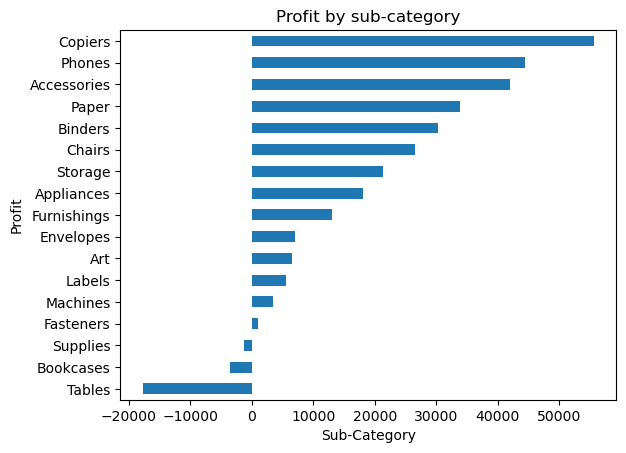

In [25]:
#profit by sub category
df.groupby('Sub-Category')['Profit'].sum().sort_values().plot(kind='barh') 
plt.title("Profit by sub-category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.show()
#Copiers and Phones are the most profitable sub-categories, while Tables and Bookcases are generating consistent losses

In [ ]:
#Although Binders show overall profit, they also contribute the highest losses in certain transactions.”
#Tables and Machines are consistently loss-making and need immediate attention.”

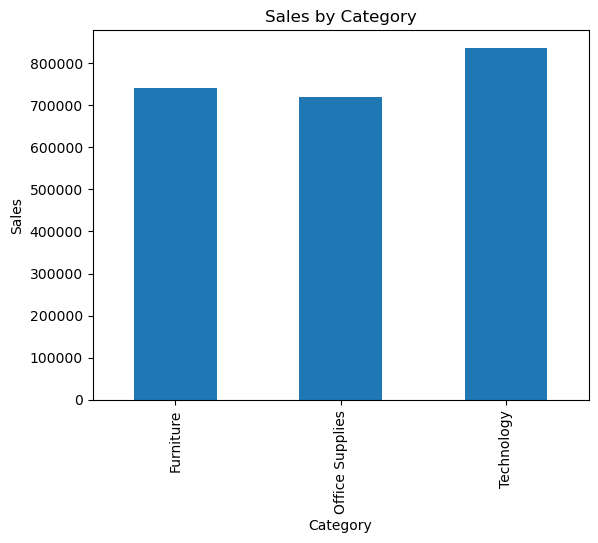

In [26]:
#sales by category
df.groupby("Category")["Sales"].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()
#Technology category generates the highest sales, while Furniture and Office Supplies contribute nearly equal but slightly lower sales

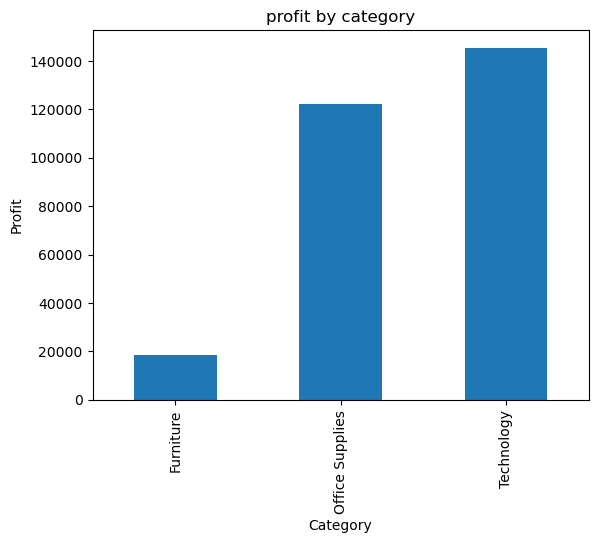

In [27]:
#Profit by Category
df.groupby("Category")["Profit"].sum().plot(kind='bar')
plt.title("profit by category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()
#Technology is the most profitable category, whereas Furniture generates the least profit despite having strong sales.
#Furniture shows a gap between sales and profit, indicating cost or discount-related issues.”

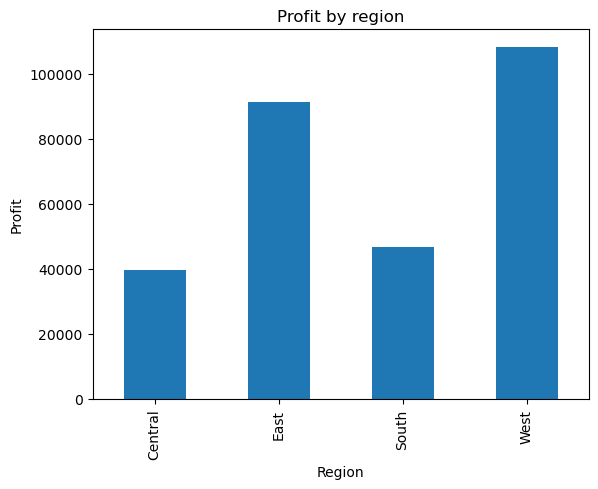

In [28]:
#profit by region 
df.groupby('Region')['Profit'].sum().plot(kind='bar')
plt.title("Profit by region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()
#The West region generates the highest profit, while the Central region underperforms

In [ ]:
# Conclusion
#The dataset was successfully cleaned by removing duplicate values and checking for missing data.
#The analysis shows that sales and profit vary across different categories.
#Some categories have higher sales but lower profit, while others are more profitable.
#Data visualization helped in understanding trends and comparing performance between categories.
# Overall, this analysis provides useful insights into business performance and decision-making.